In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('state_annual_heat_life_combined_cmip6_2020_2070.csv')

In [4]:
df.columns

Index(['state', 'state_abbr', 'year', 'scenario', 'scenario_label', 'tas_c',
       'tas_2020_c', 'tas_change_from_2020_c', 'annual_max_tasmax_c',
       'hot_days_30c', 'hot_days_30c_2020', 'hot_days_30c_change_from_2020',
       'hot_days_35c', 'hot_days_35c_2020', 'hot_days_35c_change_from_2020'],
      dtype='object')

In [13]:
df.head()

,state,state_abbr,year,scenario,scenario_label,tas_c,tas_2020_c,tas_change_from_2020_c,annual_max_tasmax_c,hot_days_30c,hot_days_30c_2020,hot_days_30c_change_from_2020,hot_days_35c,hot_days_35c_2020,hot_days_35c_change_from_2020
0,Alabama,AL,2020,ssp126,Low emissions (SSP126),15.809565,15.809565,0.000000,33.073294,37.744867,37.744867,0.000000,0.341971,0.341971,0.000000
1,Alabama,AL,2021,ssp126,Low emissions (SSP126),16.903114,15.809565,1.093548,40.702768,104.897632,37.744867,67.152766,45.387072,0.341971,45.045101
2,Alabama,AL,2022,ssp126,Low emissions (SSP126),16.508223,15.809565,0.698658,33.566757,56.948924,37.744867,19.204058,0.812273,0.341971,0.470302
3,Alabama,AL,2023,ssp126,Low emissions (SSP126),16.367164,15.809565,0.557599,35.915117,53.291383,37.744867,15.546516,6.165149,0.341971,5.823178
4,Alabama,AL,2024,ssp126,Low emissions (SSP126),17.459909,15.809565,1.650343,38.485536,91.272590,37.744867,53.527724,20.854407,0.341971,20.512436


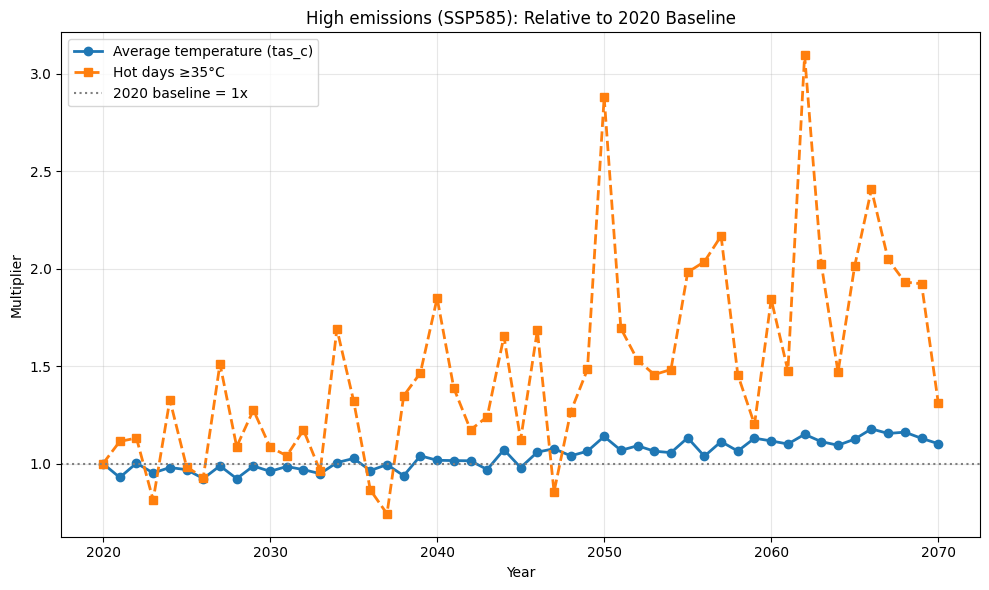

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("state_annual_heat_life_combined_cmip6_2020_2070.csv")

# only keep High emissions (SSP585)
df_high = df[df["scenario_label"] == "High emissions (SSP585)"].copy()

# annual U.S. average across all states
annual = (
    df_high.groupby("year", as_index=False)
    .agg({
        "tas_c": "mean",
        "tas_2020_c": "mean",
        "hot_days_35c": "mean",
        "hot_days_35c_2020": "mean"
    })
)

# multiplier relative to 2020 baseline
annual["tas_multiplier"] = annual["tas_c"] / annual["tas_2020_c"]

annual["hot_days_35c_multiplier"] = np.where(
    annual["hot_days_35c_2020"] == 0,
    np.nan,
    annual["hot_days_35c"] / annual["hot_days_35c_2020"]
)

# plot
plt.figure(figsize=(10, 6))

plt.plot(
    annual["year"],
    annual["tas_multiplier"],
    marker="o",
    linewidth=2,
    label="Average temperature (tas_c)"
)

plt.plot(
    annual["year"],
    annual["hot_days_35c_multiplier"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Hot days ≥35°C"
)

plt.axhline(1, color="gray", linestyle=":", linewidth=1.5, label="2020 baseline = 1x")

plt.title("High emissions (SSP585): Relative to 2020 Baseline")
plt.xlabel("Year")
plt.ylabel("Multiplier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [10]:
df['scenario_label'].unique()

array(['Low emissions (SSP126)', 'Medium emissions (SSP245)',
       'High emissions (SSP585)'], dtype=object)

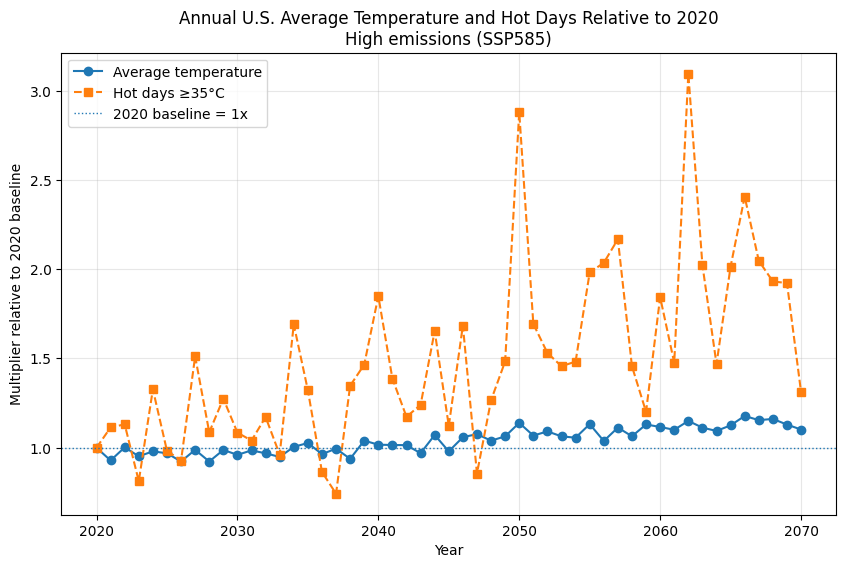

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("state_annual_heat_life_combined_cmip6_2020_2070.csv")

# only keep High emissions scenario
df_high = df[df["scenario_label"] == "High emissions (SSP585)"].copy()

# annual U.S. average across states
annual = (
    df_high.groupby(["year", "scenario_label"], as_index=False)
      .agg({
          "tas_c": "mean",
          "tas_2020_c": "mean",
          "hot_days_35c": "mean",
          "hot_days_35c_2020": "mean"
      })
)

# multiplier relative to 2020 baseline
annual["tas_multiplier"] = annual["tas_c"] / annual["tas_2020_c"]

annual["hot_days_35c_multiplier"] = np.where(
    annual["hot_days_35c_2020"] == 0,
    np.nan,
    annual["hot_days_35c"] / annual["hot_days_35c_2020"]
)

# plot
plt.figure(figsize=(10, 6))

plt.plot(
    annual["year"],
    annual["tas_multiplier"],
    marker="o",
    label="Average temperature"
)

plt.plot(
    annual["year"],
    annual["hot_days_35c_multiplier"],
    marker="s",
    linestyle="--",
    label="Hot days ≥35°C"
)

plt.axhline(1, linestyle=":", linewidth=1, label="2020 baseline = 1x")

plt.title("Annual U.S. Average Temperature and Hot Days Relative to 2020\nHigh emissions (SSP585)")
plt.xlabel("Year")
plt.ylabel("Multiplier relative to 2020 baseline")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
